# Ejercicio 8

Usando los datos del ejercicio anterior y de acuerdo a la ley de Zipf, calcule la cantidad de palabras que debería haber en el 10%, 20% y 30% del vocabulario. Verifique respecto de los valores reales. Utilice esta aproximación para podar el vocabulario en los mismos porcentajes e indique qué porcentaje de la poda coincide con palabras vacías. Extraiga las palabras podadas que no son stopwords y verifique si, a su criterio, pueden ser importantes para la recuperación.

## 1. Importar

In [11]:
import re
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import nltk
from nltk.corpus import stopwords

with open("pg2000.txt", encoding="utf-8") as f:
    texto = f.read().lower() # Paso a minusculas

# Stopwords oficiales de nltk
nltk.download("stopwords", quiet=True)
stopwords_es = set(stopwords.words("spanish"))

In [12]:
print(f"Total de palabras: {len(texto)}")

Total de palabras: 2130058


## 2. Tokenizacion

In [13]:
tokens = re.findall(r"[a-záéíóúüñ]+", texto)

total_tokens = len(tokens)
frecuencias = Counter(tokens)
ranking = frecuencias.most_common()
vocabulario = len(ranking)

print(f"Tokens: {total_tokens}")
print(f"Vocabulario: {vocabulario}")

# Frecuencias para calculos
freqs_array = np.array([freq for _, freq in ranking])
freq_acumulada = np.cumsum(freqs_array) / total_tokens
ranks = np.arange(1, vocabulario + 1)

Tokens: 386686
Vocabulario: 23575


### Ajuste Matematico de la Ley de Zipf (Regresion Log-Log)

In [14]:
# Calculamos la pendiente ideal de Zipf para compararla con la realidad
log_ranks = np.log(ranks)
log_freqs = np.log(freqs_array)
coef = np.polyfit(log_ranks, log_freqs, 1)
alpha = -coef[0]
C = np.exp(coef[1])

freqs_zipf = C * ranks**(-alpha)
freq_acum_zipf = np.cumsum(freqs_zipf) / sum(freqs_zipf)

## 3. Frecuencia

In [33]:
print("Palabra mas freceuentes:")
for palabra, freq in frecuencias.most_common(12):
    print(f"{palabra}: {freq}")

Palabra mas freceuentes:
que: 20769
de: 18411
y: 18272
la: 10492
a: 9934
en: 8285
el: 8267
no: 6356
los: 4769
se: 4752
con: 4275
por: 3945


## 4. Cobertura Real vs Teorica

Calculo del 10%, 20% y 30% del vocabulario

In [39]:
# 5. Cálculo de Cobertura y Umbrales
umbrales = [0.10, 0.20, 0.30, 0.35]
r_reales = {}
r_zipf = {}

print("--- COMPARACIÓN: REALIDAD vs LEY DE ZIPF ---")
print(f"{'Umbral':>8}  {'Real (palabras)':>18}  {'Zipf (palabras)':>18}  {'Diferencia':>12}")
print("-" * 62)
for u in umbrales:
    # np.searchsorted busca en qué momento llegamos al 10%, 20%, etc.
    r_r = int(np.searchsorted(freq_acumulada, u)) + 1
    r_z = int(np.searchsorted(freq_acum_zipf, u)) + 1
    r_reales[u] = r_r
    r_zipf[u] = r_z
    print(f"  {u*100:>5.0f}%    {r_r:>14}    {r_z:>14}    {r_r-r_z:>+10}")

--- COMPARACIÓN: REALIDAD vs LEY DE ZIPF ---
  Umbral     Real (palabras)     Zipf (palabras)    Diferencia
--------------------------------------------------------------
     10%                 2                 1            +1
     20%                 5                 1            +4
     30%                12                 3            +9
     35%                18                 3           +15


## 5. Poda del vocabulario

In [40]:
print("\n--- ANÁLISIS DE PODA (DESDE LAS MÁS FRECUENTES) ---")
for u in umbrales:
    k = r_reales[u]
    # Cortamos desde el principio (la cabeza) del ranking
    palabras_podadas = set(palabra for palabra, _ in ranking[:k])
    
    stopwords_en_poda = palabras_podadas & stopwords_es
    no_stopwords = palabras_podadas - stopwords_es
    porcentaje_sw = (len(stopwords_en_poda) / len(palabras_podadas)) * 100
    
    print(f"\nPoda Top {k} palabras (Cubre el {int(u*100)}% del texto):")
    print(f"  - Stopwords eliminadas: {len(stopwords_en_poda)} ({porcentaje_sw:.1f}%)")
    print(f"  - No-Stopwords eliminadas: {len(no_stopwords)} ({100-porcentaje_sw:.1f}%)")
    
    # Imprimimos ejemplos solo para el primer corte del 10% para no saturar la consola
    if u == 0.10:
        print(f"  - Ejemplos No-Stopwords importantes: {list(no_stopwords)[:10]}")


--- ANÁLISIS DE PODA (DESDE LAS MÁS FRECUENTES) ---

Poda Top 2 palabras (Cubre el 10% del texto):
  - Stopwords eliminadas: 2 (100.0%)
  - No-Stopwords eliminadas: 0 (0.0%)
  - Ejemplos No-Stopwords importantes: []

Poda Top 5 palabras (Cubre el 20% del texto):
  - Stopwords eliminadas: 5 (100.0%)
  - No-Stopwords eliminadas: 0 (0.0%)

Poda Top 12 palabras (Cubre el 30% del texto):
  - Stopwords eliminadas: 12 (100.0%)
  - No-Stopwords eliminadas: 0 (0.0%)

Poda Top 18 palabras (Cubre el 35% del texto):
  - Stopwords eliminadas: 17 (94.4%)
  - No-Stopwords eliminadas: 1 (5.6%)


Exploracion de No-Stopwords

In [36]:
print("\n--- EXPLORACIÓN PROFUNDA (Top 100 palabras más frecuentes) ---")

# Agarramos las 100 palabras más repetidas de todo el libro
top_100_palabras = set(palabra for palabra, _ in ranking[:100])

# Le restamos las stopwords (la magia de los Sets de Python)
no_stopwords_top100 = top_100_palabras - stopwords_es

# Para imprimirlas en orden de importancia, filtramos la lista original:
palabras_importantes_ordenadas = []
pos = 0
for palabra, freq in ranking[:100]:
  pos += 1
  if palabra not in stopwords_es:
    palabras_importantes_ordenadas.append(f"POS:{pos} - {palabra}")
#palabras_importantes_ordenadas = [palabra for palabra, freq in ranking[:100] if palabra not in stopwords_es]

print(f"Entre las 100 palabras más frecuentes, {len(palabras_importantes_ordenadas)} NO son stopwords.")
print("Aquí están (en orden de mayor a menor aparición):")
print(palabras_importantes_ordenadas)


--- EXPLORACIÓN PROFUNDA (Top 100 palabras más frecuentes) ---
Entre las 100 palabras más frecuentes, 33 NO son stopwords.
Aquí están (en orden de mayor a menor aparición):
['POS:17 - don', 'POS:21 - quijote', 'POS:22 - sancho', 'POS:26 - si', 'POS:28 - dijo', 'POS:36 - tan', 'POS:40 - señor', 'POS:41 - así', 'POS:42 - respondió', 'POS:43 - ser', 'POS:46 - bien', 'POS:49 - merced', 'POS:51 - pues', 'POS:61 - sino', 'POS:62 - dos', 'POS:63 - caballero', 'POS:69 - decir', 'POS:72 - hacer', 'POS:73 - dios', 'POS:74 - aunque', 'POS:75 - señora', 'POS:77 - aquí', 'POS:80 - aquel', 'POS:85 - mal', 'POS:88 - cosa', 'POS:89 - buen', 'POS:91 - verdad', 'POS:92 - tal', 'POS:94 - allí', 'POS:95 - ver', 'POS:97 - mundo', 'POS:98 - luego', 'POS:100 - sé']


## 6. Graficos

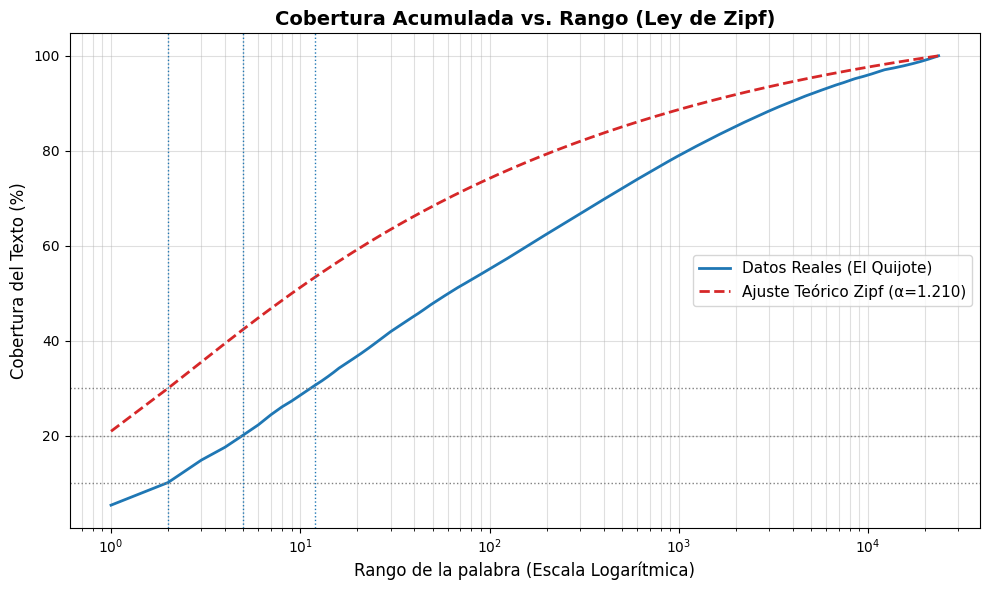

In [31]:
fig, ax = plt.subplots(figsize=(10, 6))

# Curvas principales
ax.plot(ranks, freq_acumulada * 100, color="#1f77b4", linewidth=2, label="Datos Reales (El Quijote)")
ax.plot(ranks, freq_acum_zipf * 100, color="#d62728", linewidth=2, linestyle="--", label=f"Ajuste Teórico Zipf (α={alpha:.3f})")

# Líneas de umbral (10%, 20%, 30%)
for u in umbrales:
    ax.axhline(u * 100, color="gray", linewidth=1, linestyle=":")
    ax.axvline(r_reales[u], color="#1f77b4", linewidth=1, linestyle=":")

# Configuraciones visuales
ax.set_xscale("log")
ax.set_title("Cobertura Acumulada vs. Rango (Ley de Zipf)", fontsize=14, fontweight="bold")
ax.set_xlabel("Rango de la palabra (Escala Logarítmica)", fontsize=12)
ax.set_ylabel("Cobertura del Texto (%)", fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, which="both", alpha=0.4)

plt.tight_layout()
plt.show() # Abre la ventana para que lo veas en el momento